## Implementazione DBSCAN
Definiamo per prima cosa un dataset

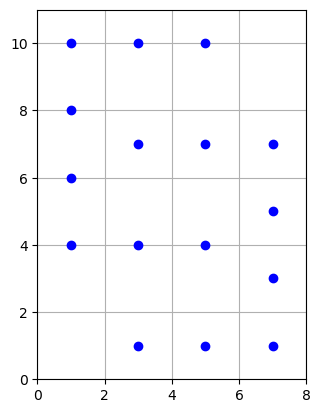

In [106]:
import matplotlib.pyplot as plt
import numpy as np

points =  [(3,1), (5,1), (7,1), (7,3), (7,5), (7,7), (5,7), (3,7),
           (5,4), (3,4), (1,4), (1,6), (1,8), (1,10), (3,10), (5,10)]

fig, ax = plt.subplots(1, 1)

ax.scatter([x for x, _ in points], [y for _, y in points], color='blue', marker='o', zorder=3)

ax.set_xlim(0, 8)
ax.set_ylim(0, 11)
ax.set_aspect('equal')
ax.grid(True)
#ax.axis('off')
plt.show()

In [114]:
from scipy.spatial import KDTree
def eps_opt(points, min_pts, draw=False):
    tree = KDTree(points)
    dists, _ = tree.query(points, min_pts)
    dists = dists[:,min_pts-1]
    n = len(dists)
    dists.sort()
    x = np.arange(n)
    y = dists
    start = np.array([0, y[0]])
    end = np.array([n-1, y[-1]])
    norma = np.linalg.norm(end - start)
    dist_AB=[]
    for i, d in enumerate(dists):
        p = np.array( [1.0*i,d] ) # il punto nel grafico k_dist
        dist_AB.append( [ np.abs(np.cross(start - end, start - p))  / norma, # distanza di p dalla retta
                     d ] ) # k_distanza, potenziale eps
    max_idx = np.argmax(dist_AB, axis=0)[0]
    eps = dist_AB[max_idx][1]
    print(eps)
    if draw:
        A = np.array([0.0, dists[0]])
        B = np.array([len(dists)-1, dists[-1]])
        # retta che unisce primo e ultimo punto in k_dits
        plt.plot( [0, len(dists)-1], [dists[0], dists[-1]], c='red')

        plt.scatter(np.arange(len(dists)), dists, s = 1)

        plt.scatter(A[0], A[1], color='red')
        plt.text(A[0]-1, A[1]+.005, 'A', color='red')
        plt.scatter(B[0], B[1], color='red')
        plt.text(B[0]-1, B[1]-.01, 'B', color='red')

        # il punto più distante dalla retta
        C = np.array( (1.0*max_idx, eps) )

        plt.scatter(C[0], C[1], color='red')
        plt.text(C[0]-1, C[1]-.01, 'C', color='red')
    return eps
def dbscan(points, min_pts, eps=None):
    '''
    points: Una sequenza di punti, o qualsiasi struttura che possa essere interpretata coma una sequenza di punti
    eps: distanza massima per essere considerato vicino
    min_pts: numero di punti minimo di vicini per essere considerato core

    Ritorna una lista label tale che labels[i] in ('Noise', '0', '1', '2', '3',...) e descrive il cluster a cui appartiene il points[i]
    '''
    points = np.array(points)
    tree = KDTree(points)
    n = points.shape[0]
    if eps==None:
        eps = eps_opt(tree, points, min_pts)
    c = -1  # c+1 sarà il 'nome' del prossimo cluster
    labels = [None]*n # non visitato

    for i, p in enumerate(points):
        if labels[i] != None:
            continue
        N = tree.query_ball_point(p, eps) # indici in points dei punti a distanza eps da p
        if len(N) < min_pts:
            labels[i] = 'Noise'
            continue
        c += 1
        labels[i] = str(c)
        S = set(N) - set([i])
        while len(S) > 0:
            j = S.pop()
            if labels[j] == 'Noise': # non core
                labels[j] = str(c)
            if labels[j] != None: # non core, altrimenti i nel cluster
                continue
            labels[j] = str(c)
            N = tree.query_ball_point(points[j], eps)
            if len(N) < min_pts:
                continue
            S.update( set(N) - set([j]) )
    return labels


**Esercizio 1**. Stimare la complessità temporale dell'algoritmo.

Esecuzione dell'algoritmo su l'istanza illustrata sopra.

In [108]:
labels = dbscan(points, eps=2, min_pts=2)
print(labels)

['0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '1', '1']


Rappresentiamo la soluzione graficamente definendo un array di colori per le due classi: `'blue'` per `'0'`, `'red'` per `'1'`.

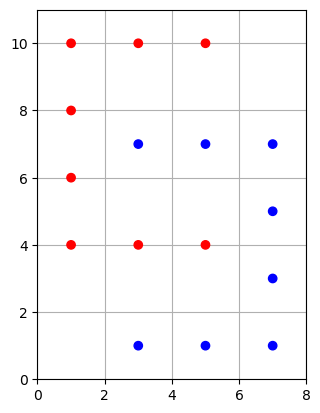

In [109]:
points =  [(3,1), (5,1), (7,1), (7,3), (7,5), (7,7), (5,7), (3,7),
           (5,4), (3,4), (1,4), (1,6), (1,8), (1,10), (3,10), (5,10)]

fig, ax = plt.subplots(1, 1)


ax.scatter([x for x, _ in points], [y for _, y in points], color= ['blue' if v == '0' else 'red' for v in labels], marker='o', zorder=3)

ax.set_xlim(0, 8)
ax.set_ylim(0, 11)
ax.set_aspect('equal')
ax.grid(True)
#ax.axis('off')
plt.show()

Ora proviamo su un dataset random

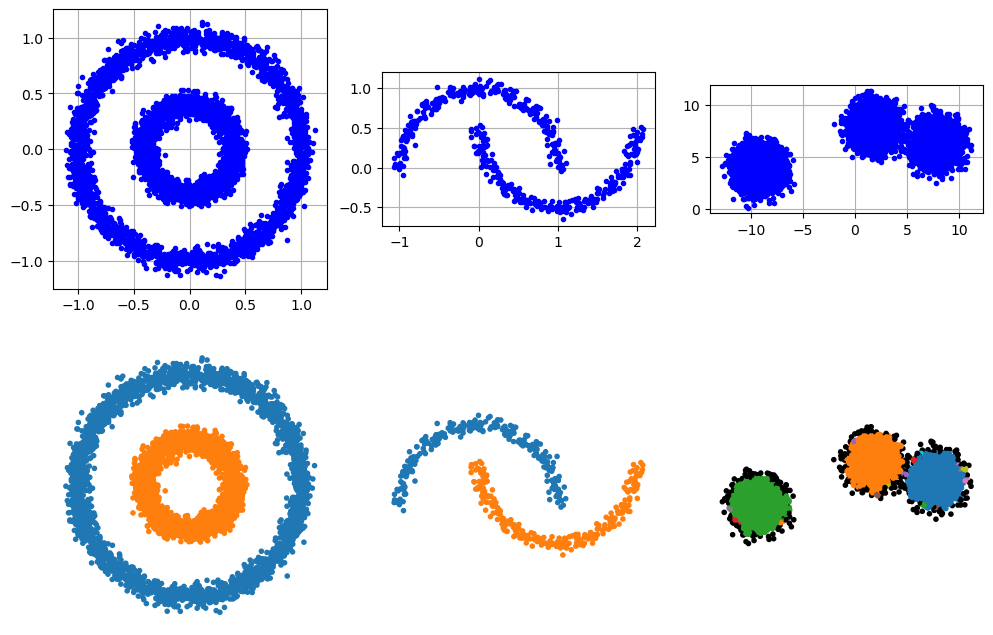

In [110]:
from sklearn import datasets
import matplotlib.colors as mcolors

noisy_circles = datasets.make_circles(n_samples=5000, factor=0.4, noise=0.05, random_state=0)
noisy_moons = datasets.make_moons(n_samples=500, noise=0.05, random_state=0)
blobs = datasets.make_blobs(n_samples=15000, center_box=(-10,10), random_state=20)

fig, axs = plt.subplots(2, 3, figsize=(12,8))

for i, the_dataset in enumerate([noisy_circles, noisy_moons, blobs]): 
    points = the_dataset[0]
    ax = axs[0][i]
    ax.scatter([x for x, _ in points], [y for _, y in points], color= 'blue', marker='.', zorder=3)
    ax.grid(True)
    ax.set_aspect('equal')
    #ax.axis('off')

color_map = list(mcolors.TABLEAU_COLORS.keys())*10

for i, the_dataset in enumerate([noisy_circles, noisy_moons, blobs]): 
    points = the_dataset[0]
    labels = dbscan(points, eps=0.2, min_pts=4)
    ax = axs[1][i]
    colors = []
    for lab in labels:
        if lab == 'Noise':
            colors.append('black')
        else:
            colors.append(color_map[int(lab)])
    ax.scatter([x for x, _ in points], [y for _, y in points], color=colors, marker='.', zorder=3)
    ax.grid(True)
    ax.set_aspect('equal')
    ax.axis('off')

## Stima del parametro `eps`

Per stimare il valore ottimale di `eps`, a ogni punto `p` si associa la distanza dal punto più lontano tra i suoi `min_pts` vicini. Le distanze così ottenute vengono ordinate in ordine crescente, ottenendo una curva che cresce lentamente all’inizio e poi aumenta bruscamente.

![gomito](materiale_2026/09-01-gomito.png)

I punti situati in zone dense presentano distanze piccole, mentre quelli in zone più isolate hanno distanze maggiori. Il punto in cui la curva cambia nettamente, il cosiddetto *gomito*, indica il confine tra zone dense e rumore. Il valore della distanza in prossimità del gomito rappresenta un buon candidato per `eps`.

Per individuarlo automaticamente, si cerca il punto della curva che ha la massima distanza dalla retta che unisce gli estremi sinistro e destro della curva, corrispondenti ai punti `A` e `B` nella figura.

**Esercizio 2**. Si utilizzi il metodo descritto per trovare il valore di `eps` consigliato per i tre dataset dell'esempio precedente.

0.03842893577658906


/var/folders/z7/w9yc0hxd58j33mlwdtcdlhrr0000gn/T/ipykernel_88180/2922477712.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_AB.append( [ np.abs(np.cross(start - end, start - p))  / norma, # distanza di p dalla retta


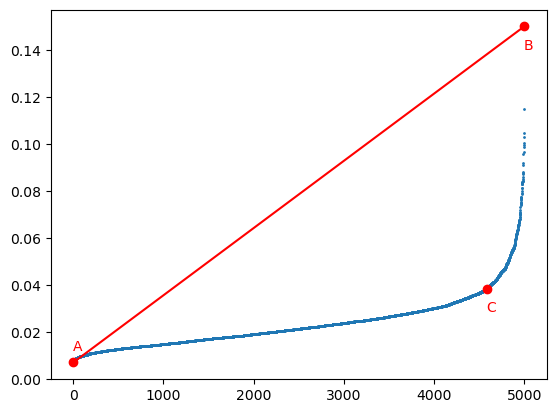

In [117]:
color_map = list(mcolors.TABLEAU_COLORS.keys())*10
points = noisy_circles[0]
eps=eps_opt(points,6,draw=True)

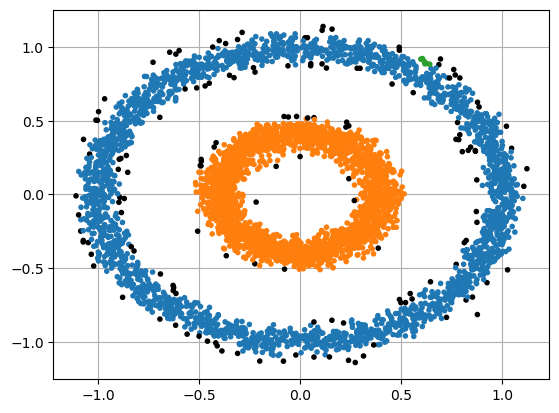

In [118]:

labels = dbscan(points, min_pts=6, eps=eps)
colors = []
for lab in labels:
    if lab == 'Noise':
        colors.append('black')
    else:
        colors.append(color_map[int(lab)])
plt.scatter([x for x, _ in points], [y for _, y in points], color=colors, marker='.', zorder=3)
plt.grid(True)